In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("wine_quality.csv", nrows=1000, header=None, usecols=[0,1,2])
df.columns=['quality','alcohol','citric acid']
df.shape

(1000, 3)

In [3]:
df.sample(5)

,quality,alcohol,citric acid
958,9.5,0.37,0.52
565,13.0,0.47,0.49
274,8.4,0.715,0.2
305,8.4,0.65,0.6
733,7.3,0.835,0.03


In [4]:
df['alcohol'].isna().sum()

np.int64(0)

In [5]:
df['alcohol']=pd.to_numeric(df['alcohol'], errors="coerce")

<Axes: xlabel='alcohol', ylabel='Density'>

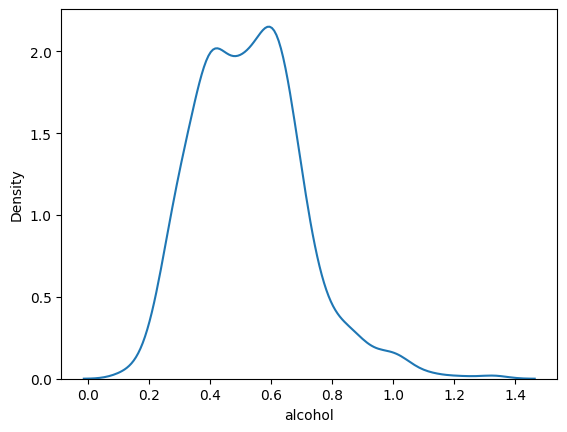

In [6]:
sns.kdeplot(df['alcohol'])

In [7]:
df['citric acid']=pd.to_numeric(df['citric acid'], errors="coerce")

In [8]:
df['quality']=pd.to_numeric(df['quality'], errors="coerce")

<Axes: xlabel='citric acid', ylabel='Density'>

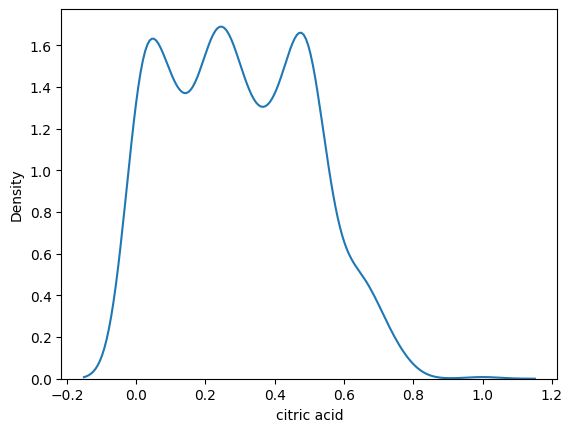

In [9]:
sns.kdeplot(df['citric acid'])

<Axes: xlabel='alcohol', ylabel='citric acid'>

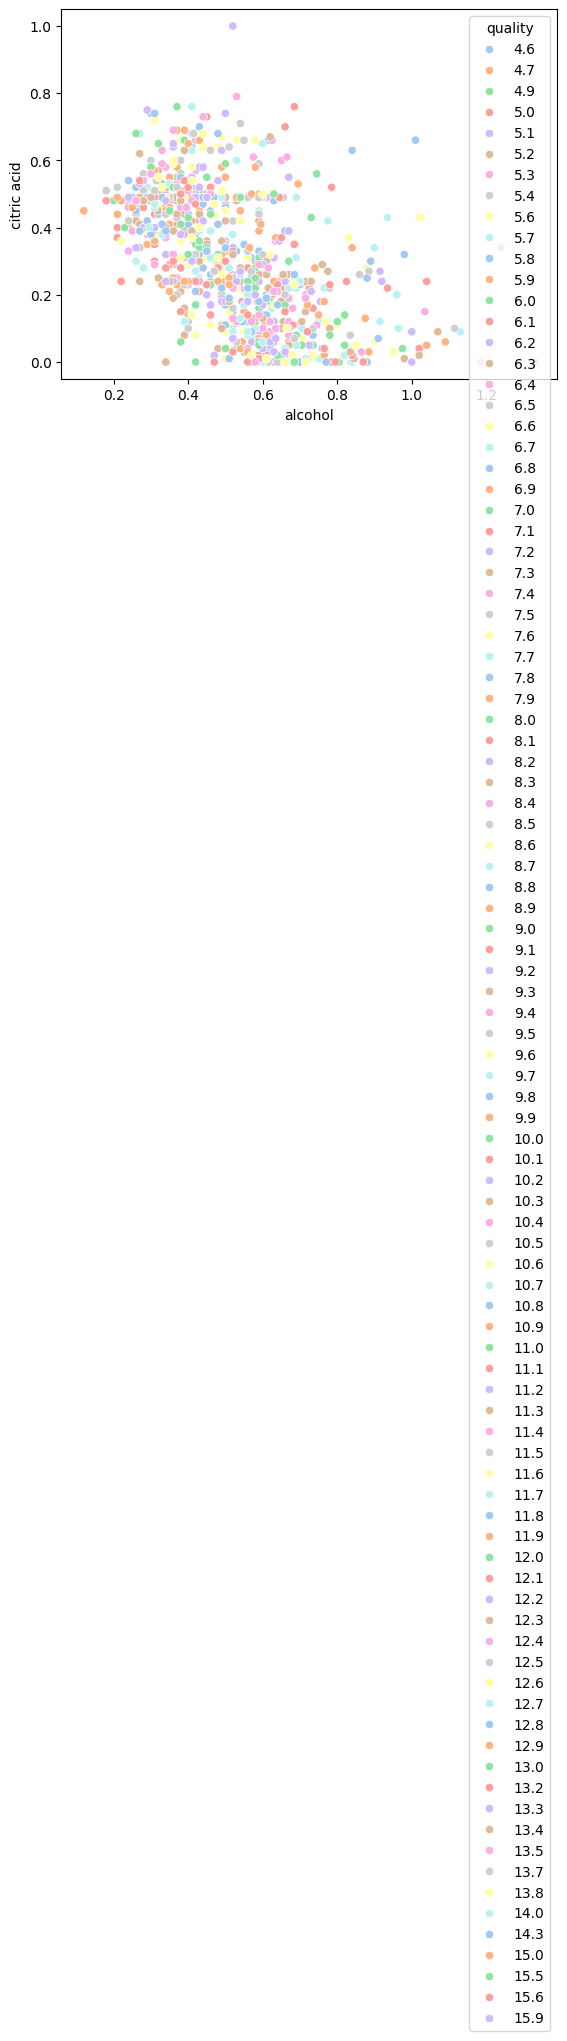

In [10]:
sns.scatterplot(x=df['alcohol'],y=df['citric acid'],hue=df['quality'],palette='pastel')

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
xtrain, xtest, ytrain, ytest=train_test_split(df.drop('quality',axis=1),df['quality'],test_size=0.2,random_state=0)
xtrain.shape, xtest.shape

((800, 2), (200, 2))

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [14]:
scaler.fit(xtrain) # fit data
# transform xtrain and xtest
xtrain_scaled=scaler.transform(xtrain) 
xtest_scaled=scaler.transform(xtest)


In [15]:
# turn to dataframe
xtrain_scaled=pd.DataFrame(xtrain_scaled,columns=xtrain.columns)
xtest_scaled=pd.DataFrame(xtest_scaled,columns=xtest.columns)

In [16]:
np.round(xtrain.describe(),1) # This uses NumPy’s round function to round all the values in the summary statistics to 1 decimal place. easier to read, especially if the raw numbers have many decimal places.

,alcohol,citric acid
count,799.0,799.0
mean,0.5,0.3
std,0.2,0.2
min,0.1,0.0
25%,0.4,0.1
50%,0.5,0.3
75%,0.6,0.5
max,1.3,1.0


In [17]:
np.round(xtrain_scaled.describe(),1) # output data is between 0 to 1 after scaling

,alcohol,citric acid
count,799.0,799.0
mean,0.3,0.3
std,0.1,0.2
min,0.0,0.0
25%,0.2,0.1
50%,0.3,0.3
75%,0.4,0.5
max,1.0,1.0


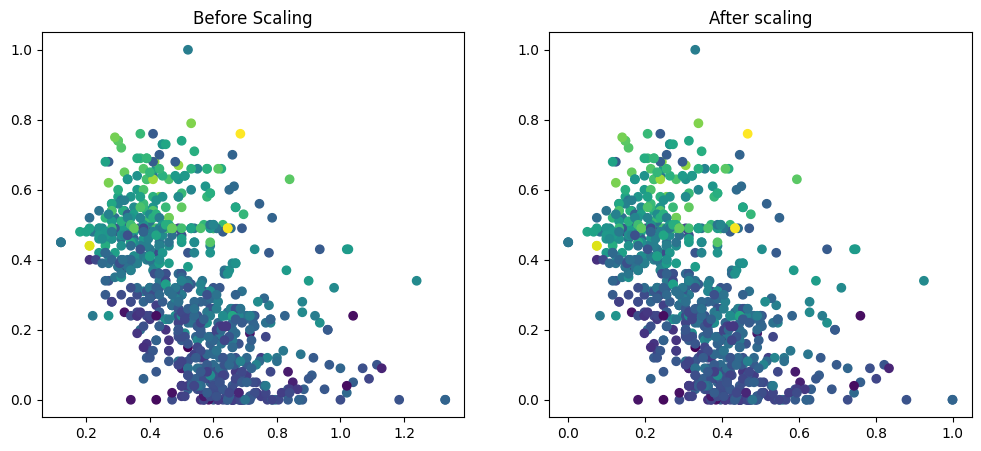

In [18]:
# creating subplots for visualization of data
fig, (ax1, ax2) =plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x=xtrain['alcohol'], y=xtrain['citric acid'], c=ytrain)
ax1.set_title("Before Scaling")
ax2.scatter(x=xtrain_scaled['alcohol'], y=xtrain_scaled['citric acid'], c=ytrain)
ax2.set_title("After scaling")
plt.show()

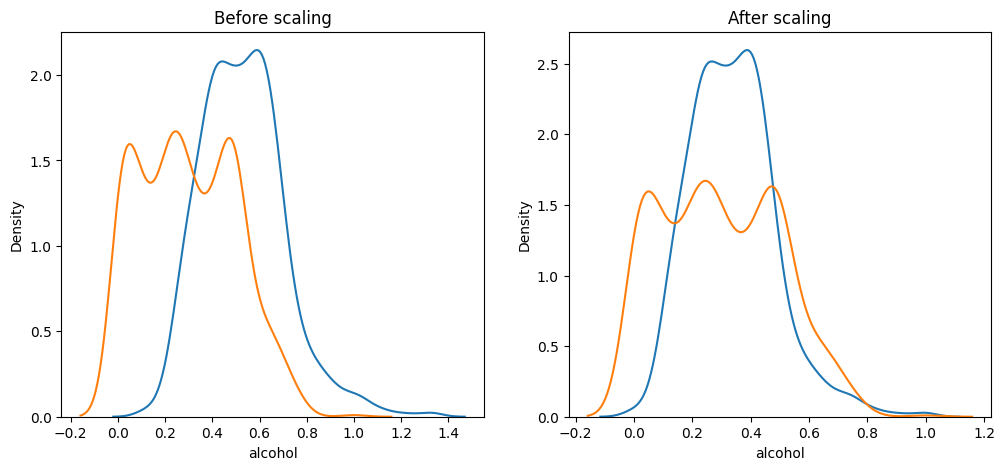

In [20]:
# kdeplots before and after scaling
fig, (ax1, ax2) =plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Before scaling")
sns.kdeplot(xtrain['alcohol'], ax=ax1)
sns.kdeplot(xtrain['citric acid'], ax=ax1)

ax2.set_title("After scaling")
sns.kdeplot(xtrain_scaled['alcohol'], ax=ax2)
sns.kdeplot(xtrain_scaled['citric acid'], ax=ax2)
plt.show()